# Статистический анализ данных сервиса аренды самокатов 

# Оглавление
1. [Описание проекта](#cell1)
2. [Загрузка данных](#cell2)
3. [Предобработка данных](#cell3)
4. [Исследовательский анализ данных](#cell4)
5. [Анализ показателей пользователей с подпиской и без подписки](#cell5)
   
   5.1 [Расстояние поездок пользователей с подпиской и без](#cell5.1)
   
   5.2 [Продолжительность поездок пользователей с подпиской и без](#cell5.2)
   
7. [Расчет выручки](#cell6)
8. [Проверка гипотез](#cell7)
9. [Распределения](#cell8)

   8.1 [Расчет количества промокодов](#cell8.1)
   
   8.2 [Рассылка push-уведомлений](#cell8.2)
   
11. [Вывод по проекту](#cell9)

<a id="cell1"></a> 
## Описание проекта

Cервис аренды самокатов GoFast предоставляет услуги по аренде самокатов в нескольких городах РФ. Пользователи сервиса  пользуются мобильным приложением для поездок по городу. 
Пользователи могут пользоваться сервисом следующими способами:
без подписки (Free):
	абонентская плата отсутствует;
	стоимость одной минуты поездки — 8 рублей;
	стоимость старта (начала поездки) — 50 рублей;
с подпиской Ultra:
	абонентская плата — 199 рублей в месяц;
	стоимость одной минуты поездки — 6 рублей;
	стоимость старта — бесплатно.
Задача менеджмента увеличить количество пользователей с подпиской.

**Исходные данные:** три датасета с информацией о пользователях, поездках и подписках

**План исследования:** 
1. загрузка и предобработка данных, в т.ч.
    - проверка на наличие пропущенных значений и дубликатов 
    - приведение типов данных к нужным форматам
2. исследовательский анализ, в т.ч.
    - оценка из каких городов пользователи, их возраста
    - соотношение пользователей с подпиской и без подписки
    - оценка расстояния, продолжительности поездок
4. объединение данных
5. расчет выручки 

6. проверка гипотез, в т.ч.
    - пользователи с подпиской тратят больше времени на поездки
    - среднее расстояние, которое проезжают пользователи с подпиской за одну поездку меньше 3130 метров
    - помесячная выручка от пользователей с подпиской по месяцам выше, чем выручка от пользователей без подписки
7. расчет показателей для отела маркетинга: расчет мин.количества промокодов, оценка вероятности открытия push-уведомленийытия push-уведомлений

In [4]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
from scipy import stats as st

<a id="cell2"></a> 
## Загрузка данных


In [6]:
users = pd.read_csv('users_go.csv')
rides = pd.read_csv('rides_go.csv')
subs = pd.read_csv('subscriptions_go.csv')

display(users.head())
display(rides.head())
subs.head()

,user_id,name,age,city,subscription_type
0,1,Кира,22,Тюмень,ultra
1,2,Станислав,31,Омск,ultra
2,3,Алексей,20,Москва,ultra
3,4,Константин,26,Ростов-на-Дону,ultra
4,5,Адель,28,Омск,ultra


,user_id,distance,duration,date
0,1,4409.919140,25.599769,2021-01-01
1,1,2617.592153,15.816871,2021-01-18
2,1,754.159807,6.232113,2021-04-20
3,1,2694.783254,18.511000,2021-08-11
4,1,4028.687306,26.265803,2021-08-28


,subscription_type,minute_price,start_ride_price,subscription_fee
0,free,8,50,0
1,ultra,6,0,199


In [7]:
# вывод основной информации
users.info()
rides.info()
subs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1565 entries, 0 to 1564
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   user_id            1565 non-null   int64 
 1   name               1565 non-null   object
 2   age                1565 non-null   int64 
 3   city               1565 non-null   object
 4   subscription_type  1565 non-null   object
dtypes: int64(2), object(3)
memory usage: 61.3+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18068 entries, 0 to 18067
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   user_id   18068 non-null  int64  
 1   distance  18068 non-null  float64
 2   duration  18068 non-null  float64
 3   date      18068 non-null  object 
dtypes: float64(2), int64(1), object(1)
memory usage: 564.8+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 4 columns):
 #   Col

<a id="cell3"></a> 

## Предобработка данных

In [9]:
# приводим все к нижнему регистру для избежания неявных дубликатов
users['name'] = users['name'].str.lower()
users['city'] = users['city'].str.lower()

In [10]:
# количество строк-дубликатов
print(users.duplicated().sum())
print(rides.duplicated().sum())
subs.duplicated().sum()

31
0


0

In [11]:
# удаление строк-дубликатов
users = users.drop_duplicates()
users.duplicated().sum()

0

In [12]:
# перевод столбца date в формат даты
rides['date'] = pd.to_datetime(rides['date'], format = '%Y-%m-%d')
rides.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18068 entries, 0 to 18067
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   user_id   18068 non-null  int64         
 1   distance  18068 non-null  float64       
 2   duration  18068 non-null  float64       
 3   date      18068 non-null  datetime64[ns]
dtypes: datetime64[ns](1), float64(2), int64(1)
memory usage: 564.8 KB


In [13]:
# проверяем за какие года данные в датасете 
rides['date'].dt.year.value_counts()

date
2021    18068
Name: count, dtype: int64

In [14]:
# новый столбец с номером месяца 
rides['month_number'] = rides['date'].dt.month
rides.head()

,user_id,distance,duration,date,month_number
0,1,4409.919140,25.599769,2021-01-01,1
1,1,2617.592153,15.816871,2021-01-18,1
2,1,754.159807,6.232113,2021-04-20,4
3,1,2694.783254,18.511000,2021-08-11,8
4,1,4028.687306,26.265803,2021-08-28,8


In [15]:
# Округление расстояния
rides['distance'] = rides['distance'].round(2)
rides['distance'].head(3)

0    4409.92
1    2617.59
2     754.16
Name: distance, dtype: float64

 
**Вывод по предобработке данных :**
- пропуски в данных отсутствуют
- столбцы с названием города и именем пользователя приведены к нижнему регистру для исключения неявных дубликатов
- строки-дубликаты имелись в датафрейме users - удалены, т.к. их количество незначительно (31 шт - 2%) и удаление не повлияет на дальнейший анализ. В остальных датафреймах явных дубликатов нет
- столбец с датой приведен к соответствующему формату 
- добавлен новый столбец с номером месяца на основе столбца 'date'
  

<a id="cell4"></a> 
## Исследовательский анализ данных

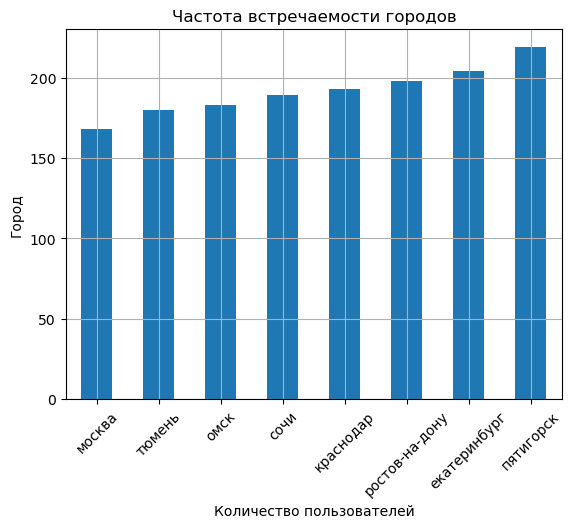

In [18]:
# общее количество уникальных городов и частота их встречаемости 
users['city'].value_counts(ascending=True).plot(
    kind='bar',
    grid = True,
    title='Частота встречаемости городов'
)
plt.xlabel('Количество пользователей')
plt.ylabel('Город')
plt.xticks(rotation=45)
plt.show()

В данных представлено 8 городов РФ, наибольшее количество пользователей приложения - в Пятигорске, наименьшее - в Москве. Вероятная причина низкого количества пользователей в Москве (в масштабах численности населения города) - конкуренция, наличие других альтернативных сервисов аренды самокатов.  

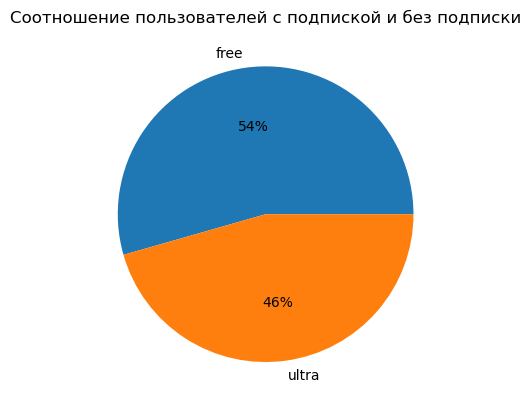

In [20]:
# соотношение пользователей с подпиской и без 
users['subscription_type'].value_counts().plot(
    kind= 'pie',
    title= 'Соотношение пользователей с подпиской и без подписки',
    autopct = "%.0f%%",
    ylabel= ""
)
plt.show()

Количество пользователей с подпиской и без разделены почти поровну, с небольшим преимуществом (54%) преобладают пользователи без подписки

In [22]:
# информация о возрасте пользователей
users['age'].describe()

count    1534.000000
mean       24.903520
std         4.572367
min        12.000000
25%        22.000000
50%        25.000000
75%        28.000000
max        43.000000
Name: age, dtype: float64

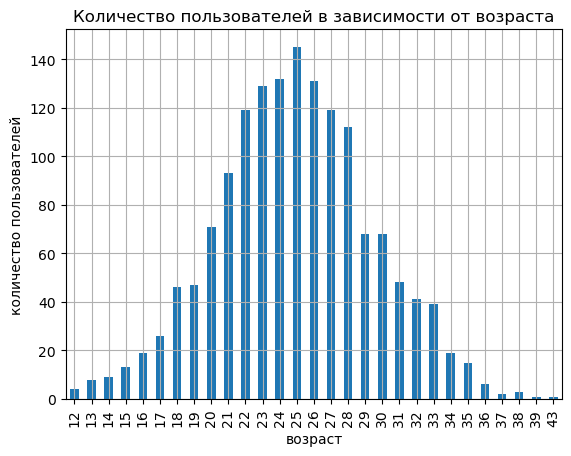

In [23]:
# диаграмма количества пользователей в разбивке по возрасту
users.groupby('age')['user_id'].agg('count').reset_index().plot(
    kind = 'bar', 
    grid = True, 
    x = 'age', 
    y = 'user_id',
    ylabel = 'количество пользователей', 
    xlabel = 'возраст',
    title= 'Количество пользователей в зависимости от возраста',
    legend = False
)
plt.show()

Распределение возраста пользователей приближено к нормальному. Средний возраст пользователей - 25 лет. Среди пользователей приложения преобладает молодежь: 75% всех пользователей имеют возраст до 28 лет. Следует отметить наличие пользователей младше 18 лет, хотя аренда самоката возможна только совершеннолетними лицами (в некоторых регионах допускается аренда с 16 лет или с 14 лет), наличие пользователей 12, 13 лет является нарушением существующих норм.

In [25]:
# информация о расстоянии одной поездки пользователей
rides['distance'].describe()

count    18068.000000
mean      3070.659992
std       1116.831222
min          0.860000
25%       2543.227500
50%       3133.610000
75%       3776.220000
max       7211.010000
Name: distance, dtype: float64

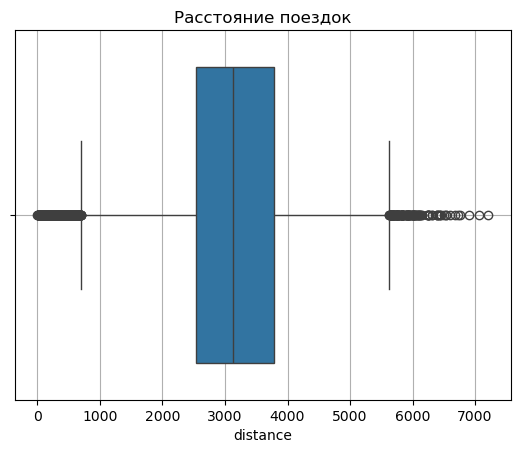

In [26]:
# диаграмма размаха расстояния поездок
rides['distance']
sns.boxplot(x='distance', data=rides) 
plt.grid()
plt.title('Расстояние поездок')
plt.show()

На диаграмме выидно большое количество выбросов: поездок менее 1 км и более 6 км, медиана расстояния  - 3,1 км

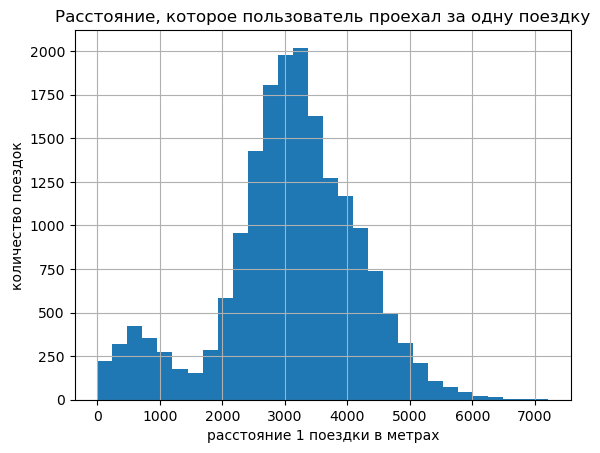

In [28]:
# диаграмма расстояния, которое пользователи проезжади за 1 поездку
rides['distance'].hist(bins = 30)
plt.xlabel('расстояние 1 поездки в метрах')
plt.ylabel('количество поездок')
plt.title('Расстояние, которое пользователь проехал за одну поездку')
plt.show()



Среднее расстояние, которое пользователь проезжает за одну поездку составляет 3070 м (медиана - 3133 м), максимальное расстояние 7211 м, однако 75% всех поездок не более 3776 м. Следует отметить наличие двух локальных максимумов на диаграмме: первый в диапазоне 400-600 м (для коротких поездок до 1000 м) и второй - 3133 м (для поездок свыше 1000 м)

In [30]:
# информация о продолжительности 1 поездки пользователей
rides['duration'].describe()

count    18068.000000
mean        17.805011
std          6.091051
min          0.500000
25%         13.597563
50%         17.678395
75%         21.724800
max         40.823963
Name: duration, dtype: float64

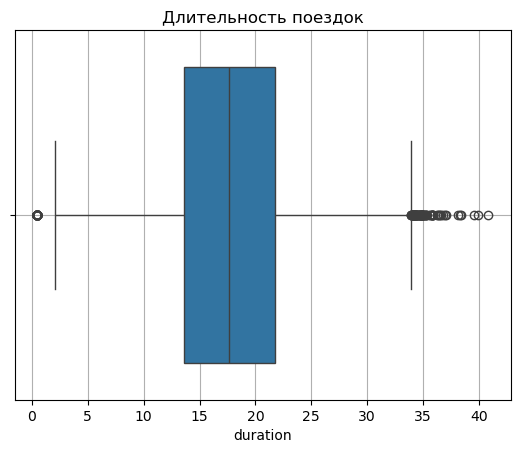

In [31]:
# диаграмма размаха длительности поездок
rides['duration']
sns.boxplot(x='duration', data=rides) 
plt.grid()
plt.title('Длительность поездок')
plt.show()

Диаграмма размаха показывает наличие выбросов: очень коротких поездок (около 0 минут) и очень длинных (более 35 мин). Данные выбросы не удаляем, т.к.  в дальнейшем это повлияет на расчет выручки сервиса аранды самокатов. 

In [33]:
# количество поездок менее 1 мин
rides.loc[rides['duration']<1,'duration'].count()


95

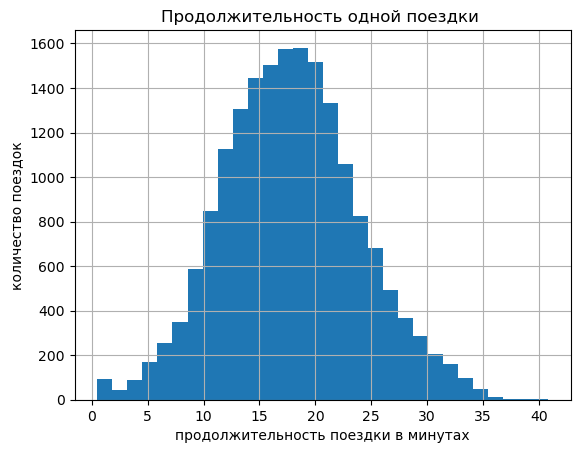

In [34]:
# диаграмма прожолжительности 1 поездки пользователей
rides['duration'].hist(bins = 30)
plt.xlabel('продолжительность поездки в минутах')
plt.ylabel('количество поездок')
plt.title('Продолжительность одной поездки ')
plt.show()

Распределение продолжительности поездок приближено к нормальному, среднее и медиана почти совпадают (17.8 мин.  и 17.7 мин. соответственно), 75% всех поездок не превышали 22 минуты. Следует отметить, наличие поездок продолжительностью менее 1 мин (всего их было 95 поездкок), что может быть вызвано проверкой пользователями работы приложения/работы самоката, а может быть техническим багом средств контроля времени поездки

**Вывод по исследовательскому анализу данных:**

- в данных представлено 8 городов РФ, наибольшее количество пользователей приложения - в Пятигорске, наименьшее - в Москве. Вероятная причина низкого количества пользователей в Москве (в масштабах численности населения города) - конкуренция, наличие других альтернативных сервисов аренды самокатов.  
- количество пользователей с подпиской и без разделены почти поровну,  преобладают пользователи без подписки (54%)
- распределение возраста пользователей приближено к нормальному. Средний возраст пользователей - 25 лет. Среди пользователей приложения преобладает молодежь: 75% всех пользователей имеют возраст до 28 лет. Следует отметить наличие пользователей младше 18 лет, хотя аренда самоката возможна только совершеннолетними лицами (в некоторых регионах допускается аренда с 16 лет или с 14 лет), наличие пользователей 12, 13 лет является нарушением существующих норм.
- среднее расстояние, которое пользователь проезжает за одну поездку составляет 3070 м (медиана - 3133 м), максимальное расстояние 7211 м, однако 75% всех поездок не более 3776 м.Следует отметить наличие двух локальных максимумов на диаграмме: первый в диапазоне 400-600 м (для коротких поездок до 1000 м) и второй - 3133 м (для поездок свыше 1000 м)
- распределение продолжительности поездок приближено к нормальному, среднее и медиана почти совпадают (17.8 мин.  и 17.7 мин. соответственно), 75% всех поездок не превышали 22 минуты. Следует отметить, что минимальное время поездки составляет 0,5 мин,  всего было 95 поездкок продолжительностью 1 минуты, что может быть вызвано проверкой пользователями работы приложения/работы самоката, а может быть техническим багом средств контроля времени поездки

<a id="cell5"></a> 
## Анализ показателей пользователей с подпиской и без подписки

In [38]:
# объединение данных о пользователях, поездках и подписках в один датафрейм
df1 = users.merge(rides, how = 'outer', on = 'user_id')
df = df1.merge(subs, how='outer', on = 'subscription_type')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18068 entries, 0 to 18067
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   user_id            18068 non-null  int64         
 1   name               18068 non-null  object        
 2   age                18068 non-null  int64         
 3   city               18068 non-null  object        
 4   subscription_type  18068 non-null  object        
 5   distance           18068 non-null  float64       
 6   duration           18068 non-null  float64       
 7   date               18068 non-null  datetime64[ns]
 8   month_number       18068 non-null  int32         
 9   minute_price       18068 non-null  int64         
 10  start_ride_price   18068 non-null  int64         
 11  subscription_fee   18068 non-null  int64         
dtypes: datetime64[ns](1), float64(2), int32(1), int64(5), object(3)
memory usage: 1.6+ MB


In [39]:
# создание датафрейма c данными о пользователях без подписки
df_free = df.loc[df['subscription_type']=='free'].reset_index(drop = True)
df_free.head()

,user_id,name,age,city,subscription_type,distance,duration,date,month_number,minute_price,start_ride_price,subscription_fee
0,700,айдар,22,омск,free,2515.69,14.944286,2021-01-02,1,8,50,0
1,700,айдар,22,омск,free,846.93,16.234663,2021-02-01,2,8,50,0
2,700,айдар,22,омск,free,4004.43,20.016628,2021-02-04,2,8,50,0
3,700,айдар,22,омск,free,1205.91,9.782872,2021-02-10,2,8,50,0
4,700,айдар,22,омск,free,3047.38,17.427673,2021-02-14,2,8,50,0


In [40]:
# создание датафрейма c данными о пользователях с подпиской
df_ultra = df.loc[df['subscription_type']=='ultra'].reset_index(drop = True)
df_ultra.head()

,user_id,name,age,city,subscription_type,distance,duration,date,month_number,minute_price,start_ride_price,subscription_fee
0,1,кира,22,тюмень,ultra,4409.92,25.599769,2021-01-01,1,6,0,199
1,1,кира,22,тюмень,ultra,2617.59,15.816871,2021-01-18,1,6,0,199
2,1,кира,22,тюмень,ultra,754.16,6.232113,2021-04-20,4,6,0,199
3,1,кира,22,тюмень,ultra,2694.78,18.511000,2021-08-11,8,6,0,199
4,1,кира,22,тюмень,ultra,4028.69,26.265803,2021-08-28,8,6,0,199


<a id="cell5.1"></a> 
### Расстояние поездок пользователей с подпиской и без

In [42]:
# без подписки
df_free['distance'].describe()

count    11568.000000
mean      3045.495284
std       1246.173810
min          0.860000
25%       2366.560000
50%       3114.650000
75%       3905.695000
max       7211.010000
Name: distance, dtype: float64

In [43]:
# с подпиской
df_ultra['distance'].describe()

count    6500.000000
mean     3115.445431
std       836.895369
min       244.210000
25%      2785.447500
50%      3148.640000
75%      3560.577500
max      5699.770000
Name: distance, dtype: float64

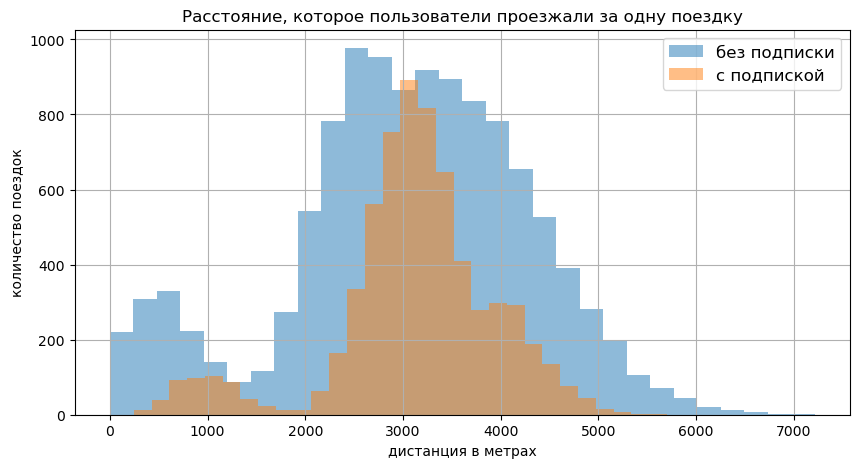

In [44]:
plt.figure(figsize=(10, 5))
plt.hist(df_free['distance'], alpha=0.5, bins = 30)
plt.hist(df_ultra['distance'], alpha=0.5, bins = 30)

plt.xlabel('дистанция в метрах')
plt.ylabel('количество поездок')
plt.grid()
plt.title('Расстояние, которое пользователи проезжали за одну поездку')
plt.legend(['без подписки','с подпиской'], loc='best', fontsize=12)
plt.show()

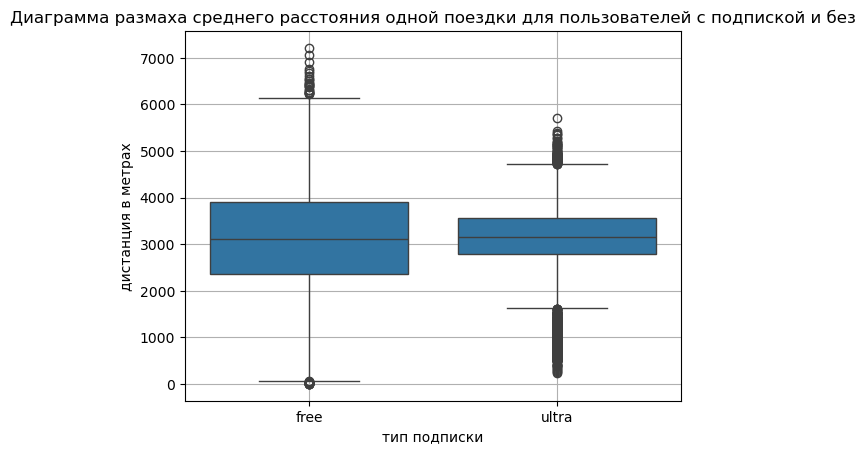

In [45]:
# строим диаграмму размаха
sns.boxplot(x='subscription_type', y='distance', data=df) 
plt.grid()  
plt.xlabel('тип подписки')
plt.ylabel('дистанция в метрах')
plt.title('Диаграмма размаха среднего расстояния одной поездки для пользователей с подпиской и без')
plt.show()

- следует отметить наличие выбросов в данных о расстояниях как для пользователей с подпиской, так и без нее. Медианное значение расстояния, которое проезжают пользователи с подпиской за одну поездку,составялет 3148 м, для пользователей без подписки медианное значение равно 3114 м
- следует отметить больший разброс данных о расстояниях для пользователей без подписки (std = 1246 m), чем для пользователей с подпиской (std = 837 m)

<a id="cell5.2"></a> 
### Продолжительность поездок пользователей с подпиской и без

In [48]:
df_free['duration'].describe()

count    11568.000000
mean        17.390909
std          6.326803
min          0.500000
25%         12.958437
50%         17.326890
75%         21.594071
max         34.948498
Name: duration, dtype: float64

In [49]:
df_ultra['duration'].describe()

count    6500.000000
mean       18.541985
std         5.572048
min         3.760353
25%        14.524654
50%        18.178153
75%        21.884129
max        40.823963
Name: duration, dtype: float64

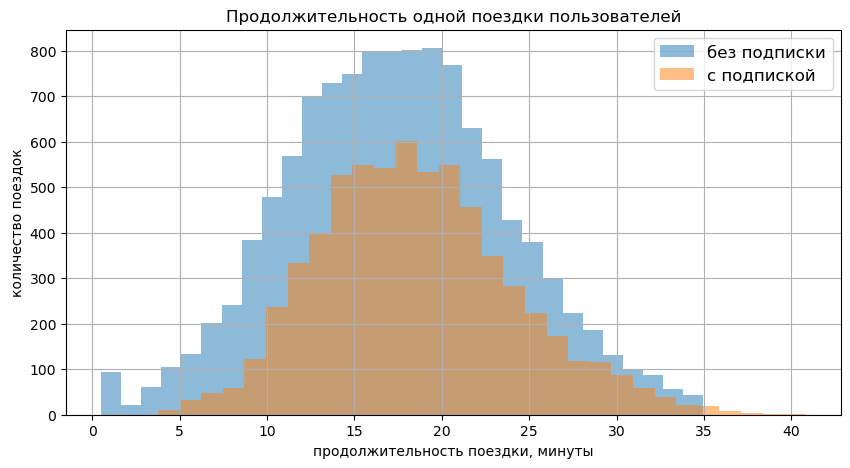

In [50]:
plt.figure(figsize=(10, 5))
plt.hist(df_free['duration'], alpha=0.5, bins = 30)
plt.hist(df_ultra['duration'], alpha=0.5, bins = 30)

plt.xlabel('продолжительность поездки, минуты')
plt.ylabel('количество поездок')
plt.grid()
plt.title('Продолжительность одной поездки пользователей')
plt.legend(['без подписки','с подпиской'], loc='best', fontsize=12)
plt.show()

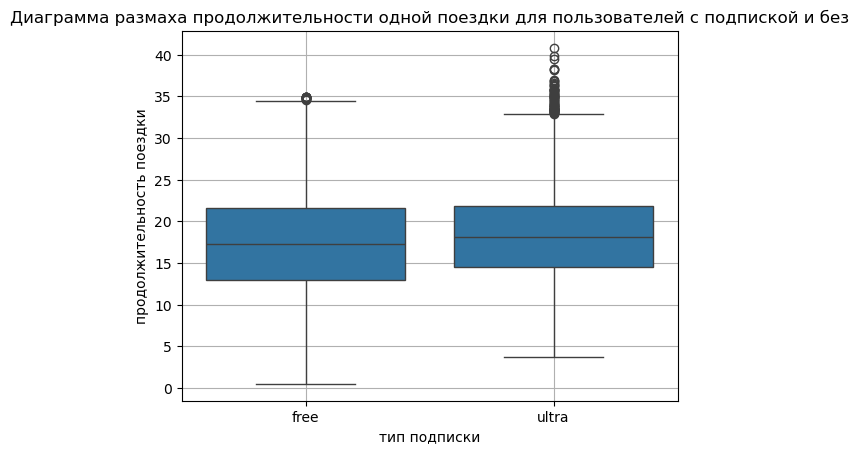

In [51]:
# строим диаграмму размаха
sns.boxplot(x='subscription_type', y='duration', data=df) 
plt.grid()  
plt.xlabel('тип подписки')
plt.ylabel('продолжительность поездки')
plt.title('Диаграмма размаха продолжительности одной поездки для пользователей с подпиской и без')
plt.show()


-  в среднем пользователи с подпиской тратят немного больше времени на поездки, чем пользователи без подписки. средняя продолжительность поездки пользователей без подписки 17.4 мин (медиана 17.3 мин), с подпиской - 18.5 мин (медиана 18.2 мин). Т.о. одна поездка пользователей с подпиской в среднем на 6% дольше, чем пользователей без подписки. 
- продолжительность одной поездки 75% всех пользователей как с подпиской, так и без нее составляет не более 22 минут
- максимальная продолжительность одной поездки пользователей с подпиской равна 41 мин, без подписки - 35 мин, однако данные значения единичны, их можно считать выбросами

<a id="cell6"></a> 
## Расчет выручки

In [54]:
# каждое значение из столбца duration округляется с помощью «потолка»: 
df['duration'] = np.ceil(df['duration']) 
df.head(10)

,user_id,name,age,city,subscription_type,distance,duration,date,month_number,minute_price,start_ride_price,subscription_fee
0,700,айдар,22,омск,free,2515.69,15.0,2021-01-02,1,8,50,0
1,700,айдар,22,омск,free,846.93,17.0,2021-02-01,2,8,50,0
2,700,айдар,22,омск,free,4004.43,21.0,2021-02-04,2,8,50,0
3,700,айдар,22,омск,free,1205.91,10.0,2021-02-10,2,8,50,0
4,700,айдар,22,омск,free,3047.38,18.0,2021-02-14,2,8,50,0
5,700,айдар,22,омск,free,4342.00,23.0,2021-02-23,2,8,50,0
6,700,айдар,22,омск,free,3798.33,19.0,2021-03-03,3,8,50,0
7,700,айдар,22,омск,free,2984.55,16.0,2021-04-09,4,8,50,0
8,700,айдар,22,омск,free,3360.11,17.0,2021-06-12,6,8,50,0
9,700,айдар,22,омск,free,2567.54,12.0,2021-06-23,6,8,50,0


In [55]:
# новый датафрейм с агрегированными данными о поездках (суммарное расстояние, количество поездок и суммарное время для каждого пользователя за каждый месяц)
# цена за минуту и за абонемент фиксирована, поэтому добавляем первое значение для каждого пользователя   

df_rev = df.groupby(['user_id', 'month_number']) \
            .agg({'distance':'sum','user_id':'count', 'duration':'sum', 'subscription_type': 'first', 'minute_price': 'first', 'start_ride_price': 'first', 'subscription_fee': 'first'}) \
            .rename(columns={'distance':'sum_distance','user_id': 'count_rides', 'duration': 'sum_duration'}) \
            .reset_index()
df_rev.head(20)

,user_id,month_number,sum_distance,count_rides,sum_duration,subscription_type,minute_price,start_ride_price,subscription_fee
0,1,1,7027.51,2,42.0,ultra,6,0,199
1,1,4,754.16,1,7.0,ultra,6,0,199
2,1,8,6723.47,2,46.0,ultra,6,0,199
3,1,10,5809.91,2,32.0,ultra,6,0,199
4,1,11,7003.50,3,56.0,ultra,6,0,199
5,1,12,6751.63,2,28.0,ultra,6,0,199
6,2,3,10187.73,3,63.0,ultra,6,0,199
7,2,4,6164.39,2,40.0,ultra,6,0,199
8,2,6,3255.34,1,14.0,ultra,6,0,199
9,2,7,6780.73,2,48.0,ultra,6,0,199


In [56]:
# проверка на пропуски нового датафрейма
df_rev.isna().sum()

user_id              0
month_number         0
sum_distance         0
count_rides          0
sum_duration         0
subscription_type    0
minute_price         0
start_ride_price     0
subscription_fee     0
dtype: int64

In [57]:
# добавляем столбец с помесячной выручкой, которую принёс каждый пользователь
df_rev['user_revenue'] = df_rev['start_ride_price'] * df_rev['count_rides'] + df_rev['minute_price'] * df_rev['sum_duration'] + df_rev['subscription_fee']

df_rev.head(10)

,user_id,month_number,sum_distance,count_rides,sum_duration,subscription_type,minute_price,start_ride_price,subscription_fee,user_revenue
0,1,1,7027.51,2,42.0,ultra,6,0,199,451.0
1,1,4,754.16,1,7.0,ultra,6,0,199,241.0
2,1,8,6723.47,2,46.0,ultra,6,0,199,475.0
3,1,10,5809.91,2,32.0,ultra,6,0,199,391.0
4,1,11,7003.50,3,56.0,ultra,6,0,199,535.0
5,1,12,6751.63,2,28.0,ultra,6,0,199,367.0
6,2,3,10187.73,3,63.0,ultra,6,0,199,577.0
7,2,4,6164.39,2,40.0,ultra,6,0,199,439.0
8,2,6,3255.34,1,14.0,ultra,6,0,199,283.0
9,2,7,6780.73,2,48.0,ultra,6,0,199,487.0


In [58]:
# расчет среднемесячной выручки пользователей с подпиской и без 
avg_ultra = df_rev.loc[df_rev['subscription_type']=='ultra','user_revenue'].mean().round(0)
print(f'среднемесячная выручка пользователей с подпиской = {avg_ultra}')

avg_free = df_rev.loc[df_rev['subscription_type']=='free','user_revenue'].mean().round(0)
print(f'среднемесячная выручка пользователей без подписки = {avg_free}')

print(f'пользователи с подпиской в среднем в месяц платят больше на {((avg_ultra/avg_free -1)*100).round(0)} %')

среднемесячная выручка пользователей с подпиской = 363.0
среднемесячная выручка пользователей без подписки = 329.0
пользователи с подпиской в среднем в месяц платят больше на 10.0 %


In [59]:
# новый датафрейм с выручкой пользователей без подписки
df_rev_free = df_rev.loc[df_rev['subscription_type']=='free'].reset_index(drop = True)
df_rev_free.head()

,user_id,month_number,sum_distance,count_rides,sum_duration,subscription_type,minute_price,start_ride_price,subscription_fee,user_revenue
0,700,1,2515.69,1,15.0,free,8,50,0,170.0
1,700,2,13446.65,5,89.0,free,8,50,0,962.0
2,700,3,3798.33,1,19.0,free,8,50,0,202.0
3,700,4,2984.55,1,16.0,free,8,50,0,178.0
4,700,6,5927.65,2,29.0,free,8,50,0,332.0


In [60]:
# новый датафрейм с выручкой пользователей с подпиской
df_rev_ultra = df_rev.loc[df_rev['subscription_type']=='ultra'].reset_index(drop = True)
df_rev_ultra.head()

,user_id,month_number,sum_distance,count_rides,sum_duration,subscription_type,minute_price,start_ride_price,subscription_fee,user_revenue
0,1,1,7027.51,2,42.0,ultra,6,0,199,451.0
1,1,4,754.16,1,7.0,ultra,6,0,199,241.0
2,1,8,6723.47,2,46.0,ultra,6,0,199,475.0
3,1,10,5809.91,2,32.0,ultra,6,0,199,391.0
4,1,11,7003.50,3,56.0,ultra,6,0,199,535.0


**Вывод расчет выручки:**
- среднемесячная выручка пользователей с подпиской составляет 363 руб, что на 10% выше, чем у пользователей без подписки (329 руб).

<a id="cell7"></a> 
##  Проверка гипотез

**Гипотеза 1:**  пользователи с подпиской тратят больше времени на поездки, чем пользователи без подписки

- Н0 : средняя продолжительность поездки пользователей с подпиской = средняя продолжительность поездки пользователей без подписки
- Н1 : средняя продолжительность поездки пользователей с подпиской > средняя продолжительность поездки пользователей без подписки

Для проверки гипотезы используем  односторонний двухвыборочный t-тест для независимых выборок.
В выборках используем  значения продолжительности поездок пользователей из сформированных в шаге 4    



In [64]:
# формируем выборки: списки значений продолжительности поездок в разбивке по пользователям с подпиской и без

ultra_duration = df_ultra['duration'].tolist()
free_duration = df_free['duration'].tolist()

print(len(ultra_duration))
print(len(free_duration))

6500
11568


In [65]:
alpha = 0.05 # уровень статистической значимости

# используем двухвыборочный t-тест для независимых выборок
results_duration = st.ttest_ind(ultra_duration, free_duration, alternative = 'greater')

print('p-значение:', results_duration.pvalue)

if results_duration.pvalue < alpha:
    print('Отвергаем нулевую гипотезу')
else:
    print('Не получилось отвергнуть нулевую гипотезу') 

p-значение: 1.2804098316645618e-34
Отвергаем нулевую гипотезу


In [66]:
# проверка средних
print(df_free['duration'].mean())
df_ultra['duration'].mean()

17.39090929866399


18.54198516280583

**Вывод:** отвергаем гипотезу о равенстве средней продолжительности поездок пользователей с подпиской и без, разница статистически значима 

**Гипотеза 2:** среднее расстояние, которое проезжают пользователи с подпиской за одну поездку, не превышает 3130  метров — оптимального расстояния с точки зрения износа самоката

- Н0 : расстояние поездки пользователей с подпиской = 3130
- Н1 : расстояние поездки пользователей с подпиской > 3130

Для проверки гипотезы используем  односторонний t-тест.
В выборках используем значения продолжительности поездок пользователей из сформированных в шаге 4 



In [69]:
# формируем выборку: список значений расстояния поездок в разбивке по пользователям с подпиской 

ultra_distance = df_ultra['distance'].tolist()

print(len(ultra_distance))


6500


In [70]:
# используем односторонний t-тест

fix_value = 3130

alpha = 0.05 # уровень статистической значимости

results_distance = st.ttest_1samp(ultra_distance, fix_value, alternative='greater')

print('p-значение:', results_distance.pvalue)

if (results_distance.pvalue < alpha):
    print('Отвергаем нулевую гипотезу')
else:
    print('Не отвергаем нулевую гипотезу') 

p-значение: 0.9195362605842414
Не отвергаем нулевую гипотезу


**Вывод:** не отвергаем нулевую гипотезу, т.е. статистически с вероятностью 95% среднее расстояние, которое проезжают пользователи с подпиской за одну поездку = 3130  метров 

**Гипотеза 3:** помесячная выручка от пользователей с подпиской по месяцам выше, чем выручка от пользователей без подписки

- Н0 : месячная выручка пользователей с подпиской = месячная выручка пользователей без подписки
- Н1 : месячная выручка пользователей с подпиской > месячная выручка пользователей без подписки

Для проверки гипотезы используем  односторонний двухвыборочный t-тест для независимых выборок.
В выборках используем все значения помесячной выручки пользователей из сформированных в шаге 4    


In [73]:
# формируем выборки: списки значений среднемесячной выручки пользователей с подпиской и без

ultra_revenue = df_rev_ultra['user_revenue'].tolist()
free_revenue = df_rev_free['user_revenue'].tolist()

print(len(ultra_revenue))
print(len(free_revenue))

4533
6798


In [74]:
alpha = 0.05 # уровень статистической значимости

# используем двухвыборочный t-тест для независимых выборок
results = st.ttest_ind(ultra_revenue, free_revenue, alternative = 'greater')

print('p-значение:', results.pvalue)

if results.pvalue < alpha:
    print('Отвергаем нулевую гипотезу')
else:
    print('Не получилось отвергнуть нулевую гипотезу') 

p-значение: 1.8850394384715216e-31
Отвергаем нулевую гипотезу


**Вывод:** отвергаем нулевую гипотезу о равенстве месячной выручки пользователей с подпиской и без, разница статистически значима



<a id="cell8"></a> 
## Распределения

<a id="cell8.1"></a> 
### Расчет количества промокодов  
Требуется провести акцию с раздачей промокодов на один бесплатный месяц подписки, в рамках которой как минимум  100 существующих клиентов должны продлить эту подписку. То есть по завершении периода действия подписки пользователь может либо отказаться от неё, либо продлить, совершив соответствующий платёж. 
Эта акция уже проводилась ранее и по итогу выяснилось, что после бесплатного пробного периода подписку продлевают 10 % пользователей. Какое минимальное количество промокодов нужно разослать, чтобы вероятность не выполнить план была примерно 5 %. 

In [78]:
# используем биноминальное распределение
from scipy.stats import binom, norm

# задаём параметры биномиального распределения
n1 = 1161 # количество промокодов (методом подбора)
p1 = 0.1 # вероятность успеха (т.е. вероятность продления подписки)
k1 = 100 # требуемое минимальное количество продлений подписки

prob = 0.05 # вероятность НЕ ВЫПОЛНИТЬ план по подпискам

for i in range(1000,2000):
    if binom.cdf(k1-1, i, p1)<=0.05:
        print('мин. кол-во промокодов', i)
        break
    



мин. кол-во промокодов 1161


In [79]:
cdf_result = binom.cdf(k1-1, n1, p1) # вероятность получить  меньше 100 продлений подписки
print('вероятность получить 100 и больше продлений подписки:', 1-cdf_result)


вероятность получить 100 и больше продлений подписки: 0.9502390990500976


**Вывод** если отправить не менее 1161 промокодов, то не менее 100 чел.продлят подписку с вероятностью 95%

<a id="cell8.2"></a> 
### Рассылка push-уведомлений 

Отдел маркетинга рассылает клиентам push-уведомления в мобильном приложении. Клиенты могут открыть его или не открывать. Известно, что уведомления открывают около 40% получивших клиентов. Отдел планирует разослать 1 млн уведомлений. С помощью аппроксимации необходимо построить примерный график распределения и оценить вероятность того, что уведомление откроют не более 399,5 тыс. пользователей.

In [82]:
# задаём параметры биномиального распределения
p2 = 0.4
n2 = 1000000
k2 = 399500

# мат.ожиданию и ст.отклонению биномиального распределения
mu = n2*p2
sigma = (n2*p2*(1-p2))**0.5

# задаём нормальное распределение
distr2 = st.norm(mu, sigma) 

# считаем вероятность, что уведомление откроют не более 399,5 тыс. пользователей
result_norm = distr2.cdf(k2)
print('вероятность, что уведомление откроют не более 399,5 тыс. пользователей составляет', result_norm.round(2)*100, '%')

вероятность, что уведомление откроют не более 399,5 тыс. пользователей составляет 15.0 %


**Вывод** 
вероятность, что уведомление откроют не более 399,5 тыс. пользователей составляет 15%

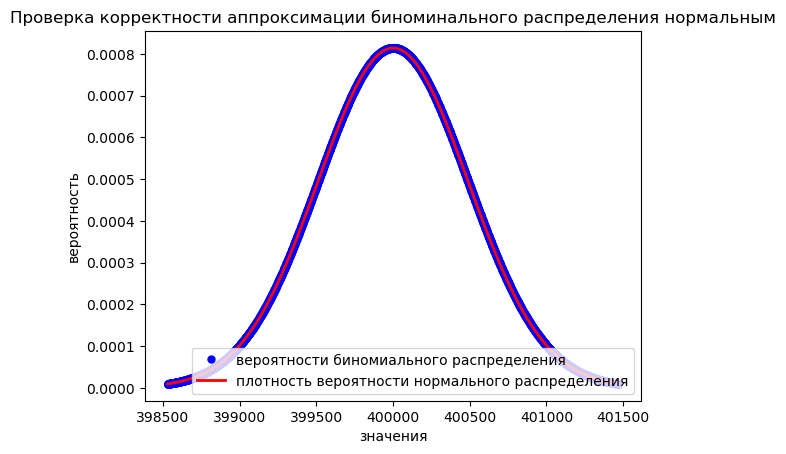

In [84]:
# зададим функцию, которая выдаёт <num> чисел, равномерно распределённых от <start> до <stop>
def linspace(start, stop, num):
    step = (stop - start) / (num - 1)
    result = []
    for i in range(num):
        result.append(start + step * i)
    return result
 
# задаём параметры биномиального распределения
p2 = 0.4
n2 = 1000000

# зададим параметры нормального распределения 
# (мат.ожидание и ст.отклонение нормального распределения принимаем равными мат.ожиданию и ст.отклонению биномиального распределения)
mu = n2 * p2
sigma = (n2 * p2 * (1 - p2))**0.5

# границы промежутка, в котором будем строить аппроксимацию - от мю минус 3 сигма до мю плюс 3 сигма 
left = int(mu - 3 * sigma)
right = int(mu + 3 * sigma)

# зададим набор значений биномиальной величины на выбранном промежутке:
# все неотрицательные целые числа от left до right
x = list(range(max(0, left), right))

# рисуем график биноминального распределения: 
ax = plt.subplot()
ax.plot(x, binom.pmf(x, n2, p2), 'bo', ms=5, label='вероятности биномиального распределения')

# рисуем график нормального распределения: 
# получим список из 100 чисел от left до right
x2 = linspace(left, right, 100)

# используем красную линию  
ax.plot(x2, norm.pdf(x2, mu, sigma), 'r-', lw=2, label='плотность вероятности нормального распределения')
plt.title('Проверка корректности аппроксимации биноминального распределения нормальным')
ax.legend(loc='lower right')
plt.ylabel('вероятность')
plt.xlabel('значения')
plt.show()

<a id="cell9"></a> 
## Вывод по проекту:

Цель проекта: проверка нескольких гипотез для оценки целесообразности увеличения пользователей с подпиской и проведения различных акций для них. Анализ показал, что количество пользователи с подпиской и без разделены почти поровну, при этом среднемесячная выручка пользователей с подпиской  на 10% выше, чем у пользователей без подписки 

**Вывод: среднемесячная выручка у пользователей с подпиской больше, чем у пользователей без подписки, разница статистически значима. Т.о. целесообразно увеличивать пользователей с подпиской.**

Более детально результаты исследования: 

В рамках проекта проведена предобработка данных, которая включала в себя:
- проверка наличия пропусков (отсутствуют)
- приведение некторых столбцов  к нижнему регистру для исключения неявных дубликатов
- удаление строк-дубликатов 
- приведение столбца с датой  к соответствующему формату 
- добавление нового столбца с номером месяца на основе столбца 'date'

Исследрвательский анализ данных показал, что: 
- в данных представлено 8 городов РФ, наибольшее количество пользователей приложения - в Пятигорске, наименьшее - в Москве. Вероятная причина низкого количества пользователей в Москве (в масштабах численности населения города) - конкуренция, наличие других альтернативных сервисов аренды самокатов  
- количество пользователей с подпиской и без разделены почти поровну, преобладают пользователи без подписки (54%)
- Среди пользователей приложения преобладает молодежь: 75% всех пользователей имеют возраст до 28 лет, средний возраст - 25 лет. Следует отметить наличие пользователей младше 18 лет, хотя аренда самоката возможна только совершеннолетними лицами (в некоторых регионах допускается аренда с 16 лет или с 14 лет), наличие пользователей 12, 13 лет является нарушением существующих норм.
- среднее расстояние, которое пользователь проезжает за одну поездку составляет 3070 м (медиана - 3133 м), 75% всех поездок не более 3776 м. 
- большая часть поездок не продолжительны по времени: 75% всех поездок не превышали 22 минуты. Следует отметить, что минимальное время поездки составляет 0,5 мин,  всего было 95 поездкок продолжительностью менее 1 минуты, что может быть вызвано проверкой пользователями работы приложения/работы самоката, а может быть техническим багом средств контроля времени поездки
- среднемесячная выручка пользователей с подпиской составляет 363 руб, что на 10% выше, чем у пользователей без подписки (329 руб)

Проверка гипотез показала, что при уровне статистической значимости 5% для всех гипотез:
- отвергаем гипотезу о равенстве средней продолжительности поездок пользователей с подпиской и без, т.е. разница статистически значима 
- статистически с вероятностью 95% среднее расстояние, которое проезжают пользователи с подпиской за одну поездку = 3130  метров 
- отвергаем нулевую гипотезу о равенстве месячной выручки пользователей с подпиской и без, т.е. разница статистически значима  

Дополнительный анализ распределений показал, что:
- если отправить не менее 1161 промокодов, то не менее 100 чел.продлят подписку с вероятностью 95%
- вероятность, что уведомление откроют не более 399,5 тыс. пользователей составляет 15%